This one is weird. Ran KFolds on training? Any reason for doing that as opposed to just waiting for test?

In [1]:
import numpy as np
import pandas as pd 

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import random
import os
import keras
from keras import optimizers
#from keras.preprocessing.image import ImageDataGenerator, load_img, image
#from keras.preprocessing.image import load_img, image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from keras.utils import to_categorical
from keras.models import Model
from keras.applications.vgg16 import VGG16
from keras.applications.vgg16 import preprocess_input
from keras.models import Sequential
from keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization

In [2]:
import os
import pandas as pd

train_dir = 'train_256/'

# list only image files (adjust extensions if needed)
filenames = [f for f in os.listdir(train_dir)
             if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

# label from filename prefix
categories = ['1' if f.endswith('yellow1.png') else '0' for f in filenames]

df = pd.DataFrame({
    'filename': filenames,
    'category': categories
})

print(df.shape)
df.head()

(432, 2)


,filename,category
0,m05_tile256_x03328_y00512_yellow0.png,0
1,m05_tile256_x02560_y00000_yellow1.png,1
2,m05_tile256_x01280_y01280_yellow1.png,1
3,m05_tile256_x01024_y03328_yellow0.png,0
4,m05_tile256_x01280_y00256_yellow0.png,0


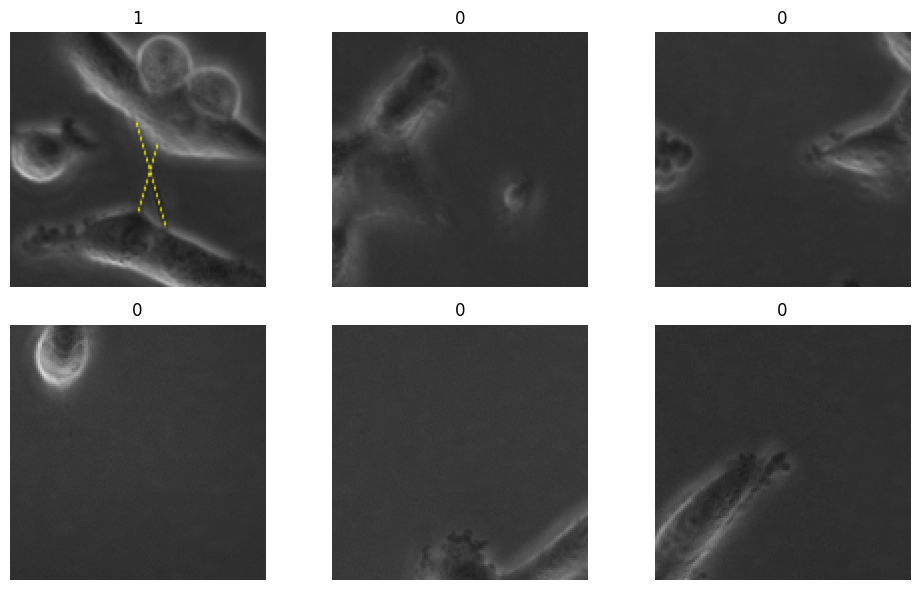

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img

IMAGE_SIZE = (128, 128)

plt.figure(figsize=(10, 6))

for i in range(6):
    sample = random.choice(df.index)
    filename = df.loc[sample, 'filename']
    category = df.loc[sample, 'category']
    
    img_path = os.path.join(train_dir, filename)
    image = load_img(img_path, target_size=IMAGE_SIZE)
    
    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(category)
    plt.axis('off')

plt.tight_layout()
plt.show()

# Bulid the model - this time with KFolds

In [12]:
# ============================================================
# TNT TILE K-FOLD TRAINING PIPELINE (VGG16) — AUTO-FIND FILES
# ============================================================

import os
import glob
import numpy as np
import pandas as pd
from pathlib import Path

import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Flatten, Dense, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, roc_auc_score

# -----------------------
# CONFIG
# -----------------------
INPUT_SHAPE = (256, 256, 3)
BATCH_SIZE = 32
EPOCHS = 20
N_SPLITS = 5
SEED = 42

# Point this at where you *think* tiles live.
# If you’re running notebook from the project root, "." is fine.
SEARCH_ROOT = Path(".")
PREFERRED_DIRS = ["train_256", "train_256/", "train", "train/", "tiles", "tiles/"]

# -----------------------
# PREP DATAFRAME
# -----------------------
df = df.copy()
print("DF columns:", list(df.columns))

# filename column
if "filename" not in df.columns:
    for c in ["file", "filepath", "path", "img", "image", "image_path"]:
        if c in df.columns:
            df = df.rename(columns={c: "filename"})
            break
assert "filename" in df.columns, "Could not find a filename/path column in df."

# label column (robust)
label_candidates = ["category", "label", "y", "target", "class", "tnt", "has_tnt"]
label_col = next((c for c in label_candidates if c in df.columns), None)
if label_col is None:
    other_cols = [c for c in df.columns if c != "filename"]
    assert len(other_cols) >= 1, "No label column found (df only has filename)."
    label_col = other_cols[0]
    print(f"Using '{label_col}' as label column (first non-filename column).")
df = df.rename(columns={label_col: "label"})

# coerce label to int 0/1
if df["label"].dtype == object:
    try:
        df["label"] = pd.to_numeric(df["label"])
    except Exception:
        mapping = {
            "tnt": 1, "yes": 1, "true": 1, "1": 1,
            "notnt": 0, "no": 0, "false": 0, "0": 0
        }
        df["label"] = df["label"].astype(str).str.lower().map(mapping)
df["label"] = df["label"].astype(int)

# ------------------------------------------------------------
# AUTO-FIND where the tiles actually are + their extension
# ------------------------------------------------------------
# Pick one example stem from df (your df has stems like: m05_tile256_x03328_y00512_yellow0)
example_stem = str(df["filename"].iloc[0])

# If df["filename"] accidentally already includes an extension, strip it
example_stem_noext = str(Path(example_stem).stem)

print("Example stem:", example_stem_noext)

# Try common image extensions
exts = [".png", ".jpg", ".jpeg", ".webp"]

def find_one_match(stem_noext: str):
    # Try preferred dirs first
    for d in PREFERRED_DIRS:
        base = SEARCH_ROOT / d
        for ext in exts:
            cand = base / f"{stem_noext}{ext}"
            if cand.exists():
                return cand

    # Fallback: glob search anywhere under SEARCH_ROOT
    for ext in exts:
        hits = list(SEARCH_ROOT.rglob(f"{stem_noext}{ext}"))
        if hits:
            return hits[0]
    return None

match_path = find_one_match(example_stem_noext)
assert match_path is not None, (
    "Could not find ANY matching tile file for the first df row.\n"
    "Check your working directory, or set SEARCH_ROOT to the folder above your tiles."
)

TILE_DIR = match_path.parent
EXT = match_path.suffix

print("Auto-detected TILE_DIR:", TILE_DIR)
print("Auto-detected EXT:", EXT)

# Build filepaths
df["filepath"] = df["filename"].astype(str).apply(lambda s: str(TILE_DIR / f"{Path(s).stem}{EXT}"))

# Verify file existence
missing_mask = ~df["filepath"].apply(os.path.exists)
missing = int(missing_mask.sum())
print(f"Missing files: {missing} / {len(df)}")

if missing:
    print("Example missing paths:")
    for p in df.loc[missing_mask, "filepath"].head(10).tolist():
        print("  ", p)
    raise FileNotFoundError(
        "Some tile files were not found even after auto-detect. "
        "Likely your filenames in df don't exactly match filenames on disk."
    )

df = df.reset_index(drop=True)
print("Label distribution:\n", df["label"].value_counts())

# -----------------------
# TF.DATA PIPELINE
# -----------------------
def load_image(path, label):
    img_bytes = tf.io.read_file(path)
    img = tf.image.decode_image(img_bytes, channels=3, expand_animations=False)
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf.image.resize(img, INPUT_SHAPE[:2])

    img = img * 255.0
    img = preprocess_input(img)

    return img, tf.cast(label, tf.float32)

def make_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(len(paths), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

# -----------------------
# MODEL FACTORY
# -----------------------
def build_model():
    vgg_base = VGG16(weights="imagenet", include_top=False, input_shape=INPUT_SHAPE)

    for layer in vgg_base.layers:
        layer.trainable = False

    unfroze = 0
    for layer in reversed(vgg_base.layers):
        if layer.weights:
            layer.trainable = True
            unfroze += 1
            if unfroze == 2:
                break

    model = Sequential([
        vgg_base,
        Flatten(),
        Dense(128, activation="relu"),
        BatchNormalization(),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

# -----------------------
# K-FOLD TRAINING
# -----------------------
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

oof_pred = np.zeros(len(df), dtype=np.float32)
oof_true = df["label"].to_numpy(np.float32)

for fold, (train_idx, val_idx) in enumerate(kf.split(df), start=1):
    print(f"\n===== Fold {fold}/{N_SPLITS} =====")

    train_ds = make_dataset(
        df.loc[train_idx, "filepath"].to_numpy(),
        df.loc[train_idx, "label"].to_numpy(),
        training=True
    )

    val_ds = make_dataset(
        df.loc[val_idx, "filepath"].to_numpy(),
        df.loc[val_idx, "label"].to_numpy(),
        training=False
    )

    model = build_model()

    callbacks = [
        EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True),
        ModelCheckpoint(
            filepath=f"tnt_vgg16_fold{fold}.keras",
            monitor="val_loss",
            save_best_only=True,
            verbose=1
        )
    ]

    model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=1
    )

    oof_pred[val_idx] = model.predict(val_ds, verbose=0).ravel()

# -----------------------
# RESULTS
# -----------------------
df["pred_proba"] = oof_pred
df["pred_label"] = (df["pred_proba"] >= 0.5).astype(int)

print("OOF Accuracy:", accuracy_score(oof_true, df["pred_label"]))
if len(np.unique(oof_true)) == 2:
    print("OOF ROC AUC :", roc_auc_score(oof_true, df["pred_proba"]))
else:
    print("OOF ROC AUC : skipped (only one class present)")

df.head()


DF columns: ['filename', 'label', 'filepath']
Example stem: m05_tile256_x03328_y00512_yellow0
Auto-detected TILE_DIR: train_256
Auto-detected EXT: .png
Missing files: 0 / 432
Label distribution:
 label
0    377
1     55
Name: count, dtype: int64

===== Fold 1/5 =====
Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6330 - loss: 0.7918
Epoch 1: val_loss improved from inf to 0.44424, saving model to tnt_vgg16_fold1.keras
11/11 ━━━━━━━━━━━━━━━━━━━━ 62s 6s/step - accuracy: 0.6351 - loss: 0.7871 - val_accuracy: 0.9195 - val_loss: 0.4442
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8545 - loss: 0.3850
Epoch 2: val_loss improved from 0.44424 to 0.14303, saving model to tnt_vgg16_fold1.keras
11/11 ━━━━━━━━━━━━━━━━━━━━ 71s 7s/step - accuracy: 0.8545 - loss: 0.3856 - val_accuracy: 0.9655 - val_loss: 0.1430
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9809 - loss: 0.0983
Epoch 3: val_loss did not improve from 0.14303
11/11 ━━━━━━━━━━━━━━━━━━━━ 74s

,filename,label,filepath,pred_proba,pred_label
0,m05_tile256_x03328_y00512_yellow0.png,0,train_256/m05_tile256_x03328_y00512_yellow0.png,0.000023,0
1,m05_tile256_x02560_y00000_yellow1.png,1,train_256/m05_tile256_x02560_y00000_yellow1.png,0.014884,0
2,m05_tile256_x01280_y01280_yellow1.png,1,train_256/m05_tile256_x01280_y01280_yellow1.png,1.000000,1
3,m05_tile256_x01024_y03328_yellow0.png,0,train_256/m05_tile256_x01024_y03328_yellow0.png,0.001285,0
4,m05_tile256_x01280_y00256_yellow0.png,0,train_256/m05_tile256_x01280_y00256_yellow0.png,0.000071,0


In [13]:
df

,filename,label,filepath,pred_proba,pred_label
0,m05_tile256_x03328_y00512_yellow0.png,0,train_256/m05_tile256_x03328_y00512_yellow0.png,0.000023,0
1,m05_tile256_x02560_y00000_yellow1.png,1,train_256/m05_tile256_x02560_y00000_yellow1.png,0.014884,0
2,m05_tile256_x01280_y01280_yellow1.png,1,train_256/m05_tile256_x01280_y01280_yellow1.png,1.000000,1
3,m05_tile256_x01024_y03328_yellow0.png,0,train_256/m05_tile256_x01024_y03328_yellow0.png,0.001285,0
4,m05_tile256_x01280_y00256_yellow0.png,0,train_256/m05_tile256_x01280_y00256_yellow0.png,0.000071,0
...,...,...,...,...,...
427,m05_tile256_x01792_y01536_yellow0.png,0,train_256/m05_tile256_x01792_y01536_yellow0.png,0.000003,0
428,m05_tile256_x03072_y02560_yellow1.png,1,train_256/m05_tile256_x03072_y02560_yellow1.png,0.000487,0
429,m05_tile256_x05632_y02048_yellow0.png,0,train_256/m05_tile256_x05632_y02048_yellow0.png,0.001329,0
430,m05_tile256_x01280_y03072_yellow0.png,0,train_256/m05_tile256_x01280_y03072_yellow0.png,0.000110,0


In [14]:
df['correct'] = (df['label'] == df['pred_label']).astype(int)
df

,filename,label,filepath,pred_proba,pred_label,correct
0,m05_tile256_x03328_y00512_yellow0.png,0,train_256/m05_tile256_x03328_y00512_yellow0.png,0.000023,0,1
1,m05_tile256_x02560_y00000_yellow1.png,1,train_256/m05_tile256_x02560_y00000_yellow1.png,0.014884,0,0
2,m05_tile256_x01280_y01280_yellow1.png,1,train_256/m05_tile256_x01280_y01280_yellow1.png,1.000000,1,1
3,m05_tile256_x01024_y03328_yellow0.png,0,train_256/m05_tile256_x01024_y03328_yellow0.png,0.001285,0,1
4,m05_tile256_x01280_y00256_yellow0.png,0,train_256/m05_tile256_x01280_y00256_yellow0.png,0.000071,0,1
...,...,...,...,...,...,...
427,m05_tile256_x01792_y01536_yellow0.png,0,train_256/m05_tile256_x01792_y01536_yellow0.png,0.000003,0,1
428,m05_tile256_x03072_y02560_yellow1.png,1,train_256/m05_tile256_x03072_y02560_yellow1.png,0.000487,0,0
429,m05_tile256_x05632_y02048_yellow0.png,0,train_256/m05_tile256_x05632_y02048_yellow0.png,0.001329,0,1
430,m05_tile256_x01280_y03072_yellow0.png,0,train_256/m05_tile256_x01280_y03072_yellow0.png,0.000110,0,1


In [16]:
df_wrong = df[df['correct'] == 0]
df_wrong.nlargest(10, 'pred_proba')

,filename,label,filepath,pred_proba,pred_label,correct
342,m05_tile256_x00256_y03840_yellow0.png,0,train_256/m05_tile256_x00256_y03840_yellow0.png,0.824933,1,0
42,m05_tile256_x03840_y03840_yellow0.png,0,train_256/m05_tile256_x03840_y03840_yellow0.png,0.804328,1,0
63,m05_tile256_x01280_y01024_yellow1.png,1,train_256/m05_tile256_x01280_y01024_yellow1.png,0.344983,0,0
1,m05_tile256_x02560_y00000_yellow1.png,1,train_256/m05_tile256_x02560_y00000_yellow1.png,0.014884,0,0
428,m05_tile256_x03072_y02560_yellow1.png,1,train_256/m05_tile256_x03072_y02560_yellow1.png,0.000487,0,0


# Test

Grid: 18 rows x 24 cols
x range: 0 to 5888 step(s): [256]
y range: 0 to 4352 step(s): [256]


,thr,acc,precision,recall,tp,fp,fn
0,0.05,0.951389,0.736111,0.963636,53,19,2
1,0.10,0.965278,0.803030,0.963636,53,13,2
2,0.15,0.976852,0.868852,0.963636,53,8,2
3,0.20,0.979167,0.883333,0.963636,53,7,2
4,0.25,0.981481,0.898305,0.963636,53,6,2
5,0.30,0.986111,0.929825,0.963636,53,4,2
6,0.35,0.988426,0.962963,0.945455,52,2,3
7,0.40,0.988426,0.962963,0.945455,52,2,3
8,0.45,0.988426,0.962963,0.945455,52,2,3
9,0.50,0.988426,0.962963,0.945455,52,2,3


Auto-picked THR (max F1): 0.85


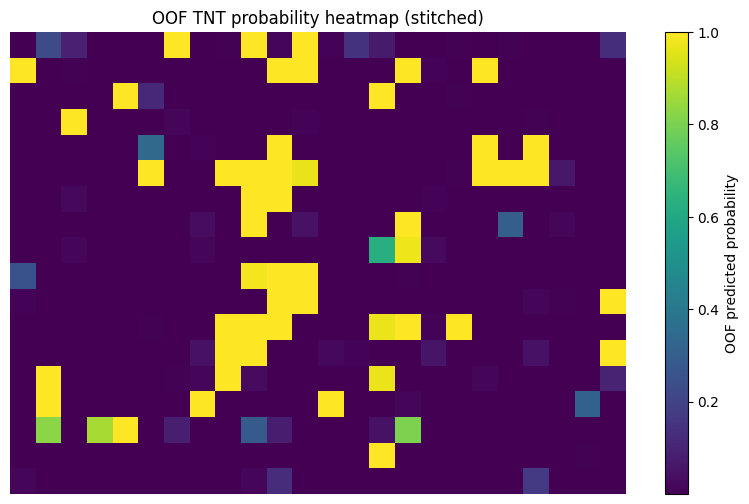

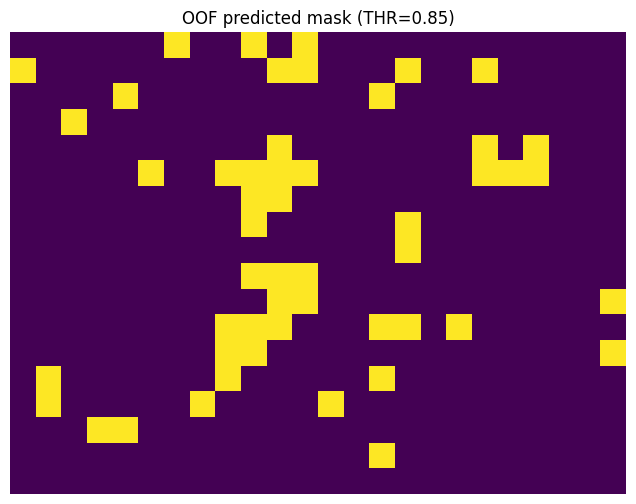

Epoch 1/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 56s 4s/step - accuracy: 0.5013 - loss: 0.9240
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 59s 4s/step - accuracy: 0.8593 - loss: 0.3923
Epoch 3/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 59s 4s/step - accuracy: 0.9876 - loss: 0.1401
Epoch 4/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 70s 5s/step - accuracy: 0.9597 - loss: 0.2007
Epoch 5/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 68s 5s/step - accuracy: 1.0000 - loss: 0.0754
Epoch 6/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 69s 5s/step - accuracy: 1.0000 - loss: 0.0503
Epoch 7/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 76s 5s/step - accuracy: 1.0000 - loss: 0.0328
Epoch 8/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 84s 6s/step - accuracy: 0.9978 - loss: 0.0321
Epoch 9/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 80s 6s/step - accuracy: 1.0000 - loss: 0.0222
Epoch 10/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 69s 5s/step - accuracy: 0.9418 - loss: 0.1385
Epoch 11/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 68s 5s/step - accuracy: 1.0000 - loss: 0.0387
Epoch 12/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 75s 5s/step - accuracy: 1.0000 - lo

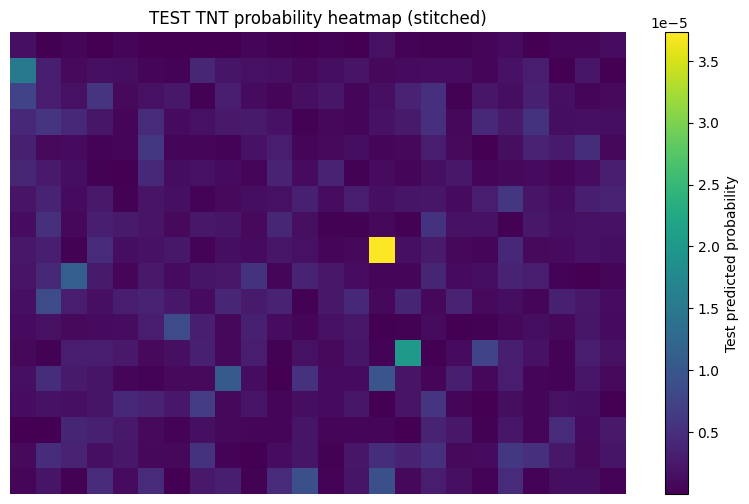

,filepath,stem,x,y,pred_proba,pred_label
0,test_256/m05_tile256_x00000_y00000_yellow0.png,m05_tile256_x00000_y00000_yellow0,0,0,0.000001,0
1,test_256/m05_tile256_x00000_y00256_yellow1.png,m05_tile256_x00000_y00256_yellow1,0,256,0.000015,0
2,test_256/m05_tile256_x00000_y00512_yellow0.png,m05_tile256_x00000_y00512_yellow0,0,512,0.000008,0
3,test_256/m05_tile256_x00000_y00768_yellow0.png,m05_tile256_x00000_y00768_yellow0,0,768,0.000004,0
4,test_256/m05_tile256_x00000_y01024_yellow0.png,m05_tile256_x00000_y01024_yellow0,0,1024,0.000003,0


In [17]:
# ============================================================
# NEXT STEPS AFTER KFOLDS:
# 1) pick threshold
# 2) stitch OOF predictions into a heatmap (tile-grid)
# 3) (optional) train final model on all + predict test_256
# 4) visualize overlays
# ============================================================

import re
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# -----------------------
# 0) Helpers: parse x/y from filename
# filename like: m05_tile256_x03328_y00512_yellow0
# -----------------------
xy_pat = re.compile(r"_x(\d+)_y(\d+)", re.IGNORECASE)

def parse_xy(stem: str):
    m = xy_pat.search(stem)
    if not m:
        return None, None
    return int(m.group(1)), int(m.group(2))

# -----------------------
# 1) Ensure df has stems + OOF preds
# -----------------------
assert "pred_proba" in df.columns, "Run KFolds first so df['pred_proba'] exists."
if "filename" not in df.columns:
    raise ValueError("Expected df['filename'] to exist (tile stem).")

df = df.copy()
df["x"] = df["filename"].apply(lambda s: parse_xy(str(s))[0])
df["y"] = df["filename"].apply(lambda s: parse_xy(str(s))[1])
assert df["x"].notna().all() and df["y"].notna().all(), "Failed to parse x/y from some filenames."

TILE = 256

# Determine grid layout from coordinates
xs = np.sort(df["x"].unique())
ys = np.sort(df["y"].unique())

ncols = len(xs)
nrows = len(ys)

print("Grid:", nrows, "rows x", ncols, "cols")
print("x range:", xs.min(), "to", xs.max(), "step(s):", np.unique(np.diff(xs))[:5])
print("y range:", ys.min(), "to", ys.max(), "step(s):", np.unique(np.diff(ys))[:5])

# Map x/y -> row/col index
x_to_col = {x:i for i, x in enumerate(xs)}
y_to_row = {y:i for i, y in enumerate(ys)}

df["row"] = df["y"].map(y_to_row)
df["col"] = df["x"].map(x_to_col)

# -----------------------
# 2) Pick a threshold (start with 0.5, but you should tune)
# If you have labels in df['label'], show a quick sweep
# -----------------------
if "label" in df.columns:
    y_true = df["label"].to_numpy()
    probs  = df["pred_proba"].to_numpy()

    thresholds = np.linspace(0.05, 0.95, 19)
    rows = []
    for t in thresholds:
        pred = (probs >= t).astype(int)
        acc = (pred == y_true).mean()
        # precision/recall (avoid div0)
        tp = np.sum((pred==1) & (y_true==1))
        fp = np.sum((pred==1) & (y_true==0))
        fn = np.sum((pred==0) & (y_true==1))
        prec = tp / (tp+fp) if (tp+fp) else 0.0
        rec  = tp / (tp+fn) if (tp+fn) else 0.0
        rows.append((t, acc, prec, rec, tp, fp, fn))
    sweep = pd.DataFrame(rows, columns=["thr","acc","precision","recall","tp","fp","fn"])
    display(sweep)

    # simple default: choose threshold with highest F1
    f1 = 2*sweep["precision"]*sweep["recall"] / (sweep["precision"]+sweep["recall"]).replace(0, np.nan)
    best_i = np.nanargmax(f1.to_numpy())
    THR = float(sweep.loc[best_i, "thr"])
    print("Auto-picked THR (max F1):", THR)
else:
    THR = 0.5
    print("No df['label'] found; using THR=0.5")

# -----------------------
# 3) Stitch OOF probabilities into a heatmap image
# -----------------------
proba_grid = np.full((nrows, ncols), np.nan, dtype=np.float32)
pred_grid  = np.zeros((nrows, ncols), dtype=np.uint8)

for _, r in df.iterrows():
    rr, cc = int(r["row"]), int(r["col"])
    proba_grid[rr, cc] = float(r["pred_proba"])
    pred_grid[rr, cc]  = 1 if float(r["pred_proba"]) >= THR else 0

# Upsample to pixel map (each tile becomes TILE x TILE block)
proba_map = np.kron(proba_grid, np.ones((TILE, TILE), dtype=np.float32))
mask_map  = np.kron(pred_grid,  np.ones((TILE, TILE), dtype=np.uint8))

plt.figure(figsize=(10,6))
plt.imshow(proba_map, interpolation="nearest")
plt.colorbar(label="OOF predicted probability")
plt.title("OOF TNT probability heatmap (stitched)")
plt.axis("off")
plt.show()

plt.figure(figsize=(10,6))
plt.imshow(mask_map, interpolation="nearest")
plt.title(f"OOF predicted mask (THR={THR:.2f})")
plt.axis("off")
plt.show()

# -----------------------
# 4) OPTIONAL: train final model on all labeled tiles then predict test_256/
# (This gives your best map on the no-line image)
# Requires your earlier functions: build_model(), make_dataset()
# -----------------------
DO_FINAL_TEST_INFER = True

if DO_FINAL_TEST_INFER:
    test_dir = Path("test_256")
    # try to reuse the same EXT you used earlier; if unknown, grab from disk
    test_files = sorted(list(test_dir.glob("*.png")) + list(test_dir.glob("*.jpg")) + list(test_dir.glob("*.jpeg")) + list(test_dir.glob("*.webp")))
    assert len(test_files) > 0, f"No image files found in {test_dir}"

    test_paths = np.array([str(p) for p in test_files])
    dummy = np.zeros(len(test_paths), dtype=np.float32)

    # Train final model on all data
    final_model = build_model()
    final_model.fit(
        make_dataset(df["filepath"].to_numpy(), df["label"].to_numpy(), training=True),
        epochs=EPOCHS,
        verbose=1
    )

    # Predict test tiles
    test_pred = final_model.predict(make_dataset(test_paths, dummy, training=False), verbose=0).ravel()

    # Build a test_df with parsed x/y if filenames match pattern
    test_df = pd.DataFrame({"filepath": test_paths})
    test_df["stem"] = test_df["filepath"].apply(lambda p: Path(p).stem)
    test_df["x"] = test_df["stem"].apply(lambda s: parse_xy(str(s))[0])
    test_df["y"] = test_df["stem"].apply(lambda s: parse_xy(str(s))[1])
    test_df["pred_proba"] = test_pred
    test_df["pred_label"] = (test_df["pred_proba"] >= THR).astype(int)

    # If parse worked, stitch test heatmap too
    if test_df["x"].notna().all() and test_df["y"].notna().all():
        xs2 = np.sort(test_df["x"].unique())
        ys2 = np.sort(test_df["y"].unique())
        x2 = {x:i for i,x in enumerate(xs2)}
        y2 = {y:i for i,y in enumerate(ys2)}
        ncols2, nrows2 = len(xs2), len(ys2)

        proba_grid2 = np.full((nrows2, ncols2), np.nan, dtype=np.float32)
        for _, r in test_df.iterrows():
            proba_grid2[y2[int(r["y"])], x2[int(r["x"])]] = float(r["pred_proba"])
        proba_map2 = np.kron(proba_grid2, np.ones((TILE, TILE), dtype=np.float32))

        plt.figure(figsize=(10,6))
        plt.imshow(proba_map2, interpolation="nearest")
        plt.colorbar(label="Test predicted probability")
        plt.title("TEST TNT probability heatmap (stitched)")
        plt.axis("off")
        plt.show()

    display(test_df.head())


# Test
Add this after K Fold Block

In [ ]:
# ============================================================
# FINAL TRAIN ON ALL DATA → PREDICT test_256/
# ============================================================

TEST_DIR = Path("test_256")
EXT = EXT  # already auto-detected earlier

# Build test filepaths (same stem logic)
test_files = sorted(TEST_DIR.glob(f"*{EXT}"))
assert len(test_files) > 0, "No test files found in test_256/"

test_paths = np.array([str(p) for p in test_files])

# Dummy labels (not used, but required by dataset API)
dummy_labels = np.zeros(len(test_paths), dtype=np.float32)

test_ds = make_dataset(test_paths, dummy_labels, training=False)

# Train final model on ALL tiles
final_model = build_model()

final_callbacks = [
    EarlyStopping(monitor="loss", patience=2, restore_best_weights=True),
    ModelCheckpoint(
        filepath="tnt_vgg16_final.keras",
        monitor="loss",
        save_best_only=True,
        verbose=1
    )
]

final_model.fit(
    make_dataset(
        df["filepath"].to_numpy(),
        df["label"].to_numpy(),
        training=True
    ),
    epochs=EPOCHS,
    callbacks=final_callbacks,
    verbose=1
)

# Predict test tiles
test_pred_proba = final_model.predict(test_ds, verbose=0).ravel()
test_pred_label = (test_pred_proba >= 0.5).astype(int)

# Store results
test_df = pd.DataFrame({
    "filepath": test_paths,
    "pred_proba": test_pred_proba,
    "pred_label": test_pred_label
})

test_df.head()


# OLD STUFF